# 03 · OLS Varsayımları ve Regresyon Tanılaması (Regression Diagnostics)
**Statistical Inference Lab**

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Bu, seri içindeki **en kritik notebook'lardan biri** — çünkü lineer regresyon, makine
> öğrenmesindeki neredeyse her modelin (lojistik regresyon, GLM'ler, hatta sinir ağlarının
> son katmanı) atasıdır. `probability-lab` 08'de (MLE=OLS) regresyonun **matematiksel
> temelini** görmüştük — burada o temelin **pratikte ayakta durup durmadığını** test etmeyi
> öğreneceğiz. Bir regresyon modelinin p-value'larına, güven aralıklarına, hatta katsayı
> işaretlerine güvenebilmen için, modelin **varsayımlarının** gerçekten sağlandığından emin
> olman gerekiyor — sağlanmıyorsa, model sana yanlış hikayeler anlatabilir.

**Önkoşul:** MLE=OLS bağlantısı (`probability-lab` 08), Normal Dağılım (03a), Hipotez Testi (01)  
**Veri:**  
- `auto-mpg.data` — 398 araç (UCI Auto MPG, yakıt tüketimi ve teknik özellikler)  
**Araçlar:** Python (statsmodels, scipy), R (base R `lm()`)

---
## 1 · Büyük Resim: Neden Varsayımları Kontrol Ediyoruz?

Bir regresyon modeli kurduğunda (`sklearn.LinearRegression()` ya da `statsmodels.OLS()`),
kütüphane **her zaman** sana katsayılar, p-value'lar, $R^2$ verir — veri ne kadar "çirkin"
olursa olsun, kod asla "bu varsayımların ihlal edildiğini" söyleyip seni uyarmaz. Bu, tehlikeli
bir durum yaratıyor: **istatistiksel olarak "anlamlı" görünen bir sonuç, aslında tamamen
yanıltıcı olabilir** — çünkü p-value ve güven aralığı hesaplamalarının **arkasında**, belirli
varsayımların doğru olduğu kabul ediliyor.

**Somut bir benzetme:** Bir cetvel düşün. Eğer cetvel eğilmişse (varsayım ihlali), onunla
yaptığın her ölçüm (katsayı, p-value, CI) yanlış çıkar — ama cetvele bakınca "eğilmiş" olduğunu
göremezsin, sadece ölçüm sonucunu görürsün. Bu notebook'ta öğreneceğimiz, "cetvelin eğilip
eğilmediğini" nasıl kontrol edeceğimiz.

---
## 2 · OLS'in Varsayımları — Özet Harita

Lineer regresyonun (basit ifadeyle $Y = \beta_0 + \beta_1 X + \epsilon$) güvenilir olması için
hata terimi ($\epsilon$) hakkında **dört temel varsayım**, artı bir de pratik sorun var:

| # | Varsayım | Kısa Tanım | İhlal Edilirse |
|---|---|---|---|
| 1 | **Doğrusallık** | $X$ ve $Y$ arasındaki ilişki gerçekten doğrusal | Katsayılar anlamsız, tahminler sistematik yanlış |
| 2 | **Bağımsızlık** | Hata terimleri birbirinden bağımsız | Standart hatalar yanlış (genelde olduğundan küçük) |
| 3 | **Homoscedasticity** | Hata varyansı $X$'in her değerinde sabit | Standart hatalar yanlış, CI/p-value güvenilmez |
| 4 | **Normallik** | Hatalar Normal dağılıyor | Küçük örneklemde CI/p-value güvenilmez (büyük n'de CLT kurtarır) |
| + | **Multicollinearity Yok** | Bağımsız değişkenler birbirinden çok etkilenmiyor | Katsayı işaretleri/büyüklükleri kararsızlaşır |

Bu beşini sırayla, **önce sentetik "ders kitabı" örnekleriyle** (varsayımın açıkça ihlal
edildiği/edilmediği durumları net görmek için), **sonra gerçek Auto MPG verisiyle** işleyeceğiz.

---
## 3 · Varsayım 1 — Doğrusallık (Linearity)

**Ne demek?** $X$ değişkenindeki bir birimlik artışın, $Y$ üzerinde HER ZAMAN aynı etkiyi
yaratması (sabit eğim). Eğer gerçek ilişki eğrisel (kuadratik, logaritmik, vs.) ise, düz bir
çizgi zorla uydurmak sistematik hatalar üretir.

**Nasıl test edilir?** **Residual vs Fitted (Tahmin) grafiği.** Modelin tahmin ettiği değerleri
x-eksenine, hataları (residual = gerçek - tahmin) y-eksenine koyarsın. Eğer doğrusallık
sağlanıyorsa, noktalar **rastgele bir bulut** gibi sıfır çizgisi etrafında dağılmalı — hiçbir
"desen" (eğri, U-şekli, vs.) olmamalı. Bir desen varsa, model verideki eğriselliği yakalayamıyor demektir.

---
## 4 · Varsayım 2 — Bağımsızlık (Independence)

**Ne demek?** Bir gözlemin hatası, başka bir gözlemin hatasını **etkilememeli.** En sık
ihlal edildiği yer: **zaman serisi** verisi (bugünkü hata, dünkü hatayla ilişkiliyse — buna
"otokorelasyon" denir) veya **gruplu/hiyerarşik** veri (aynı hastane/şehirdeki gözlemler
birbirine benzeme eğiliminde).

**Nasıl test edilir?** Zaman serisi bağlamında **Durbin-Watson istatistiği** yaygın kullanılır
(2'ye yakınsa bağımsızlık sağlanıyor demektir, 0'a yakınsa güçlü pozitif otokorelasyon var).
Auto MPG verisi zaman serisi olmadığı için bu notebook'ta detaylandırmıyoruz, ama bilmen
gereken önemli bir kavram — ileride zaman serisi verisiyle çalışırken karşına çıkacak.

---
## 5 · Varsayım 3 — Homoscedasticity (Sabit Varyans)

**Ne demek?** Hataların "yayılımı" (varyansı), $X$'in her değerinde **aynı** olmalı.
"Heteroscedasticity" (değişken varyans) durumunda, tahminlerin belirsizliği $X$'e göre değişir
— örneğin ucuz evlerde fiyat tahmini kesin ama pahalı evlerde çok belirsiz olabilir.

**Nasıl test edilir?** Yine **Residual vs Fitted grafiği** — ama bu sefer aradığın desen farklı:
klasik **"huni şekli"** (fitted değerler arttıkça residual'ların yayılımı artıyor/azalıyor).
Formal test: **Breusch-Pagan testi** — residual karelerinin, bağımsız değişkenlerle ne kadar
ilişkili olduğunu test ediyor (ilişkiliyse varyans sabit değil demektir).

---
## 6 · Varsayım 4 — Normal Dağılan Hatalar

**Ne demek?** Hata terimlerinin (residuals) Normal dağılması gerekiyor — **DİKKAT:** bu,
$X$ veya $Y$'nin kendisinin Normal dağılması gerektiği anlamına GELMİYOR, sadece model
hatalarının.

**Neden önemli? (05'teki CLT bağlantısı)** Katsayıların güven aralığı ve p-value'ları, hata
teriminin Normal dağıldığı varsayımına dayanıyor. Eğer $n$ çok büyükse, CLT (probability-lab
06b) devreye girip bu varsayımı kısmen "kurtarıyor" (katsayı tahminlerinin kendisi CLT
sayesinde Normal'e yakınsıyor) — ama küçük örneklemde bu güvence yok, varsayımı doğrudan
kontrol etmen gerekiyor.

**Nasıl test edilir?** **Q-Q Plot** (residual'ların teorik Normal dağılımla karşılaştırılması
— noktalar düz bir çizgiye ne kadar yakınsa o kadar iyi) + **Shapiro-Wilk testi** (formal
istatistiksel test, $H_0$: veri Normal dağılıyor).

---
## 7 · Ekstra Sorun — Multicollinearity (Çoklu-Doğrusal Bağlantı)

Bu, hata terimiyle ilgili bir varsayım değil, **bağımsız değişkenlerin kendi aralarındaki**
bir sorun. İki (veya daha fazla) bağımsız değişken birbirine çok yüksek korelasyonluysa
(örn. bir aracın "ağırlığı" ve "hacmi" — biri artınca diğeri de artar), model bu iki
değişkenin **etkisini birbirinden ayırt edemez.**

**Sonuç:** Katsayılar kararsızlaşır — veri setine küçük bir değişiklik yaptığında (birkaç
gözlem eklesen/çıkarsan) katsayılar çılgınca değişebilir, hatta işaretleri (+/-) bile
gerçek etkiyle **ters** çıkabilir.

**Nasıl test edilir?** **VIF (Variance Inflation Factor).** Her bağımsız değişkeni, DİĞER
tüm bağımsız değişkenlerle tahmin etmeye çalışırsın (bir yardımcı regresyon) — eğer bu
yardımcı regresyonun $R^2$'si yüksekse (yani bu değişken diğerlerinden iyi tahmin
edilebiliyorsa), o değişken "fazlalık" bilgi taşıyor demektir:
$$VIF_j = \frac{1}{1-R_j^2}$$

**Kural of thumb:** $VIF > 5$ (bazı kaynaklarda $>10$) endişe verici kabul edilir.

---
## 8 · Varsayımlar İhlal Edilirse Ne Yapılır? (Çözüm Haritası)

| İhlal | Olası Çözüm |
|---|---|
| Doğrusallık | Değişkeni dönüştür (log, kare, karekök) veya polinom terim ekle |
| Bağımsızlık | Zaman serisi modelleri (ARIMA vb.) veya karma etkiler modeli |
| Homoscedasticity | Log dönüşümü (genelde işe yarar), Weighted Least Squares, "robust" standart hatalar |
| Normallik | Büyük $n$'de CLT zaten kurtarır; küçük $n$'de dönüşüm veya bootstrap (10b) |
| Multicollinearity | Korelasyonlu değişkenlerden birini çıkar, veya Ridge regresyon (`linear-algebra-lab`'daki norm/regularizasyon konusuna bağlı) |

Python bölümünde bu çözümlerden **log dönüşümünü** somut olarak uygulayıp, "önce/sonra"
karşılaştırması yapacağız.

---
## 9 · Görsel Özet: Dört Varsayım İhlalini Tek Bakışta Görmek

Aşağıda, `covariance_correlation.ipynb`'daki Anscombe Dörtlüsü'nün ruhuna uygun bir
gösterim var: **sentetik olarak** üretilmiş 4 senaryo — biri "temiz" (tüm varsayımlar
sağlanıyor), diğer üçü sırasıyla doğrusallık, homoscedasticity ve normallik varsayımlarını
**kasıtlı olarak** ihlal ediyor. Her senaryonun hem scatter+regresyon çizgisini hem de
residual grafiğini yan yana göreceksin — gerçek veriye geçmeden önce "neye bakmam gerektiğini"
gözünde netleştirmek için.

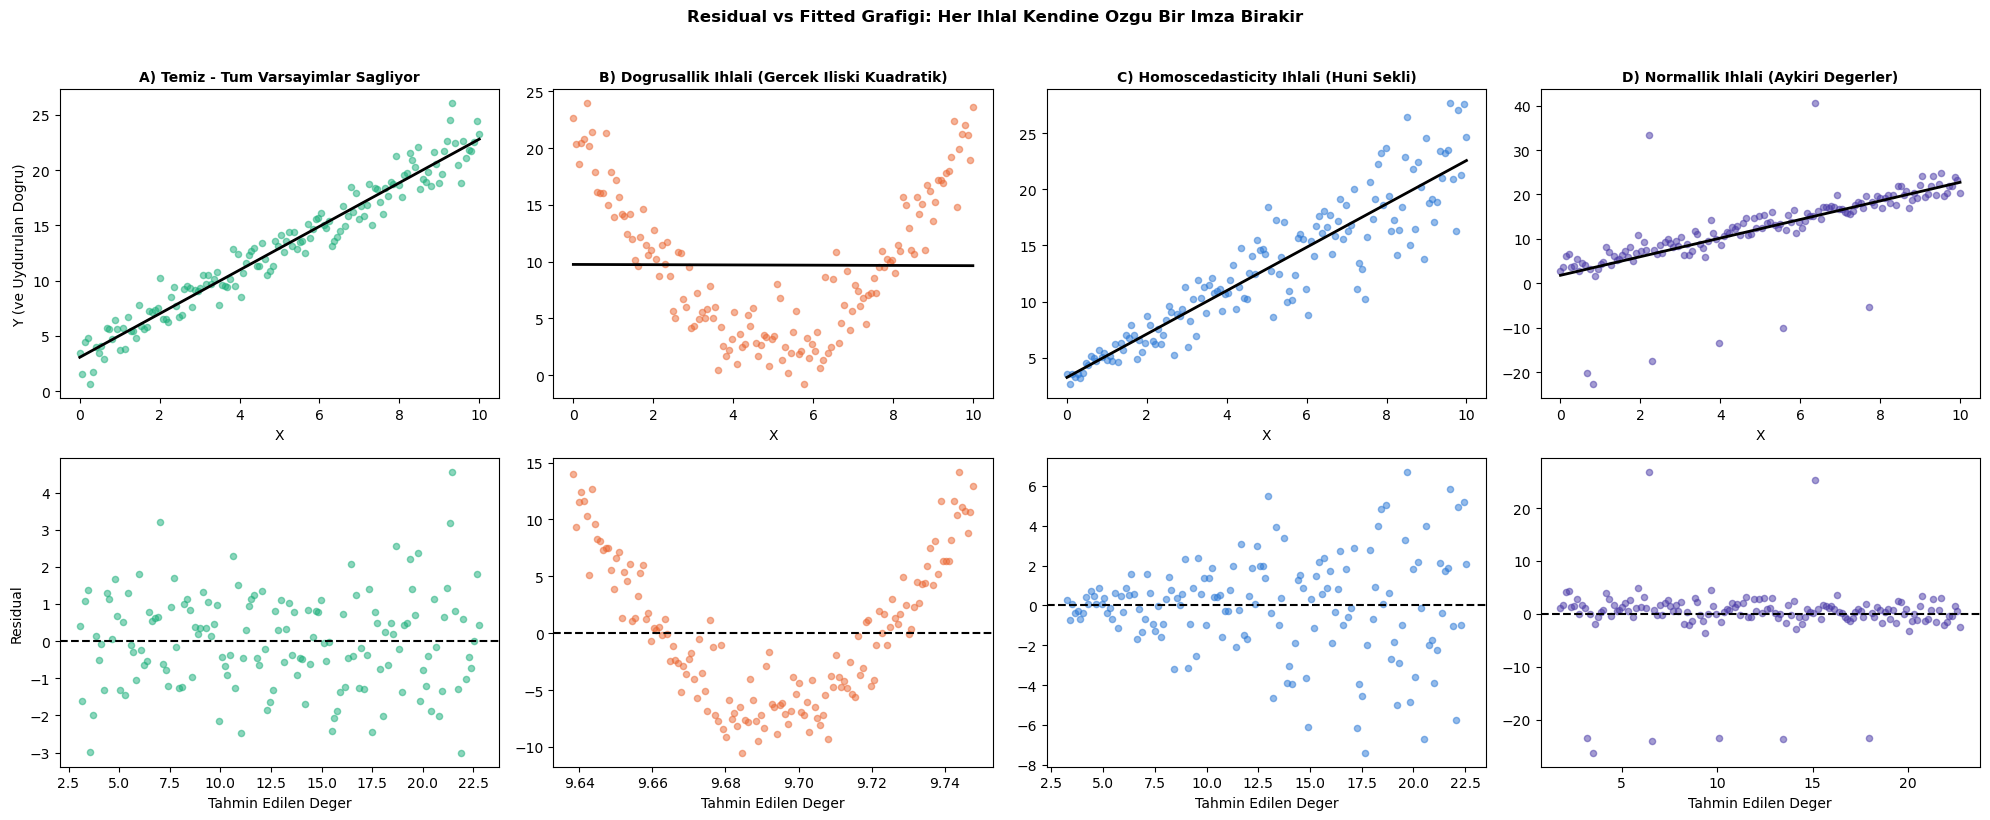

NASIL OKUNUR:
A) Residual bulutu rastgele, desensiz - IDEAL durum
B) Residual'lar U-sekli ciziyor - model egriselligi yakalayamiyor
C) Residual'lar saga dogru genisliyor (huni) - varyans sabit degil
D) Cogu nokta normal ama birkac uc deger var - agir kuyruklu/carpik hata dagilimi


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
n = 150
x = np.linspace(0, 10, n)

# Senaryo A: TEMIZ - dogrusal iliski, sabit varyans, normal hata
y_temiz = 3 + 2*x + rng.normal(0, 1.5, n)

# Senaryo B: DOGRUSALLIK IHLALI - gercek iliski kuadratik ama duz cizgi uyduruyoruz
y_nonlinear = 3 + 0.8*(x-5)**2 + rng.normal(0, 2, n)

# Senaryo C: HOMOSCEDASTICITY IHLALI - varyans x arttikca artiyor (huni sekli)
y_hetero = 3 + 2*x + rng.normal(0, 0.3 + 0.4*x, n)

# Senaryo D: NORMALLIK IHLALI - birkac asiri aykiri deger (outlier) hatalari çarpitiyor
y_outlier = 3 + 2*x + rng.normal(0, 1.5, n)
outlier_idx = rng.choice(n, 8, replace=False)
y_outlier[outlier_idx] += rng.choice([-25, 25], 8)

senaryolar = [
    ('A) Temiz - Tum Varsayimlar Sagliyor', y_temiz, '#1baf7a'),
    ('B) Dogrusallik Ihlali (Gercek Iliski Kuadratik)', y_nonlinear, '#eb6834'),
    ('C) Homoscedasticity Ihlali (Huni Sekli)', y_hetero, '#2a78d6'),
    ('D) Normallik Ihlali (Aykiri Degerler)', y_outlier, '#4a3aa7'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, (baslik, y, renk) in enumerate(senaryolar):
    katsayilar = np.polyfit(x, y, 1)
    y_tahmin = np.polyval(katsayilar, x)
    residuals = y - y_tahmin

    axes[0, i].scatter(x, y, alpha=0.5, color=renk, s=20)
    axes[0, i].plot(x, y_tahmin, color='black', linewidth=2)
    axes[0, i].set_title(baslik, fontsize=10, fontweight='bold')
    axes[0, i].set_xlabel('X')
    if i == 0:
        axes[0, i].set_ylabel('Y (ve Uydurulan Dogru)')

    axes[1, i].scatter(y_tahmin, residuals, alpha=0.5, color=renk, s=20)
    axes[1, i].axhline(0, color='black', linestyle='--', linewidth=1.5)
    axes[1, i].set_xlabel('Tahmin Edilen Deger')
    if i == 0:
        axes[1, i].set_ylabel('Residual')

plt.suptitle('Residual vs Fitted Grafigi: Her Ihlal Kendine Ozgu Bir Imza Birakir', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("NASIL OKUNUR:")
print("A) Residual bulutu rastgele, desensiz - IDEAL durum")
print("B) Residual'lar U-sekli ciziyor - model egriselligi yakalayamiyor")
print("C) Residual'lar saga dogru genisliyor (huni) - varyans sabit degil")
print("D) Cogu nokta normal ama birkac uc deger var - agir kuyruklu/carpik hata dagilimi")


---
# 🐍 Python Uygulaması

6 adımda ilerleyeceğiz (bu konu kritik olduğu için normalden daha kapsamlı):
1. **Veriyi Hazırlama ve İlk Model** — Auto MPG için temel regresyon modeli kurma
2. **Residual vs Fitted** — Doğrusallık ve homoscedasticity'yi aynı grafikte kontrol etme
3. **Multicollinearity** — VIF hesaplama, `weight` ve `displacement`'ın "fazlalık" bilgisi
4. **Homoscedasticity — Formal Test** — Breusch-Pagan testi (elle + kütüphane)
5. **Normallik Kontrolü** — Q-Q plot + Shapiro-Wilk testi
6. **Sorunu Çözme** — Log dönüşümüyle "önce/sonra" karşılaştırması

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🚗 Python 1 — Veriyi Hazırlama ve İlk Model

**Ne yapıyoruz?**  
`auto-mpg.data` standart CSV değil — boşlukla ayrılmış, eksik değerler `?` ile işaretli.
Temizledikten sonra `mpg ~ weight + horsepower + displacement + acceleration` modelini kuruyoruz.

In [3]:
kolonlar = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
            'acceleration', 'model_year', 'origin', 'car_name']
auto = pd.read_csv('data/auto-mpg.data', sep=r'\s+', names=kolonlar, na_values='?')
print(f"Ham veri: {auto.shape[0]} satır")

auto_temiz = auto.dropna(subset=['horsepower']).copy()
print(f"Temizlik sonrası (horsepower eksik olanlar çıkarıldı): {auto_temiz.shape[0]} satır")
print(auto_temiz[['mpg', 'weight', 'horsepower', 'displacement', 'acceleration']].describe())

# statsmodels formul arayuzu - R'in formul sozdizimine cok benziyor (bilerek boyle secildi)
model = smf.ols('mpg ~ weight + horsepower + displacement + acceleration', data=auto_temiz).fit()
print(model.summary())

Ham veri: 398 satır
Temizlik sonrası (horsepower eksik olanlar çıkarıldı): 392 satır
              mpg       weight  horsepower  displacement  acceleration
count  392.000000   392.000000  392.000000    392.000000    392.000000
mean    23.445918  2977.584184  104.469388    194.411990     15.541327
std      7.805007   849.402560   38.491160    104.644004      2.758864
min      9.000000  1613.000000   46.000000     68.000000      8.000000
25%     17.000000  2225.250000   75.000000    105.000000     13.775000
50%     22.750000  2803.500000   93.500000    151.000000     15.500000
75%     29.000000  3614.750000  126.000000    275.750000     17.025000
max     46.600000  5140.000000  230.000000    455.000000     24.800000
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares  

---
### 📉 Python 2 — Residual vs Fitted: Doğrusallık ve Homoscedasticity Aynı Anda

**Ne yapıyoruz?**  
Bölüm 9'daki sentetik örneklerde gördüğümüz "imzaları" gerçek modelde arıyoruz — Auto MPG'de
`mpg` ile `weight`/`horsepower` arasındaki ilişki gerçekte biraz eğriseldir (bu klasik bir
bulgu bu veri setinde), bunu grafikte görebilecek misin?

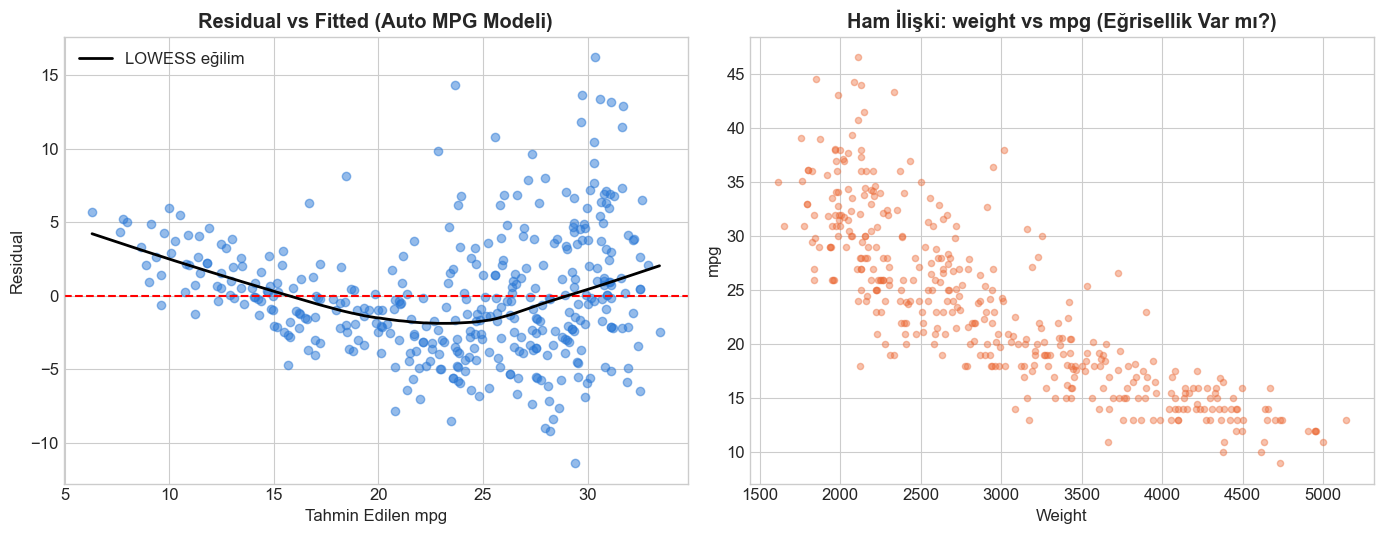

YORUM: LOWESS çizgisi tamamen düz DEĞİL - hafif bir eğrilik var, özellikle düşük ve
yüksek tahmin değerlerinde. Bu, 'weight vs mpg' ilişkisinin tam doğrusal olmadığının
bir işareti - araç ağırlığı arttıkça yakıt tüketimindeki kötüleşme SABİT bir oranda değil.
Sağdaki grafikte de görüldüğü gibi ham ilişki hafif eğrisel görünüyor (düz çizgiden çok
bir eğriye benziyor) - Bölüm 6'da (Python 6) buna log dönüşümüyle çözüm arayacağız.


In [4]:
tahminler = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(tahminler, residuals, alpha=0.5, color='#2a78d6')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
# LOWESS (yerel agirlikli duzgunlestirme) egrisi - egilim varsa gorsellestirir
from statsmodels.nonparametric.smoothers_lowess import lowess
smoothed = lowess(residuals, tahminler)
axes[0].plot(smoothed[:, 0], smoothed[:, 1], color='black', linewidth=2, label='LOWESS eğilim')
axes[0].set_xlabel('Tahmin Edilen mpg')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residual vs Fitted (Auto MPG Modeli)', fontweight='bold')
axes[0].legend()

axes[1].scatter(auto_temiz['weight'], auto_temiz['mpg'], alpha=0.4, color='#eb6834', s=20)
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('mpg')
axes[1].set_title('Ham İlişki: weight vs mpg (Eğrisellik Var mı?)', fontweight='bold')

plt.tight_layout()
plt.show()

print("YORUM: LOWESS çizgisi tamamen düz DEĞİL - hafif bir eğrilik var, özellikle düşük ve")
print("yüksek tahmin değerlerinde. Bu, 'weight vs mpg' ilişkisinin tam doğrusal olmadığının")
print("bir işareti - araç ağırlığı arttıkça yakıt tüketimindeki kötüleşme SABİT bir oranda değil.")
print("Sağdaki grafikte de görüldüğü gibi ham ilişki hafif eğrisel görünüyor (düz çizgiden çok")
print("bir eğriye benziyor) - Bölüm 6'da (Python 6) buna log dönüşümüyle çözüm arayacağız.")

---
### 🔗 Python 3 — Multicollinearity: VIF Hesaplama

**Ne yapıyoruz?**  
`weight`, `horsepower`, `displacement` — üçü de "aracın büyüklüğü/gücü" ile ilgili, birbirleriyle
yüksek korelasyonlu olmaları bekleniyor. VIF ile bunu sayısallaştırıyoruz.

    degisken       VIF
      weight 10.284456
  horsepower  8.823022
displacement 10.686922
acceleration  2.603255

YORUM: VIF > 5 (bazı kaynaklarda >10) endişe verici kabul edilir.
Yüksek VIF'li değişkenler: ['weight', 'horsepower', 'displacement']
Bu değişkenler birbirlerinin bilgisini büyük ölçüde 'tekrar ediyor' - modelin
bu değişkenlerin bireysel etkisini güvenle ayırt etmesi zor.


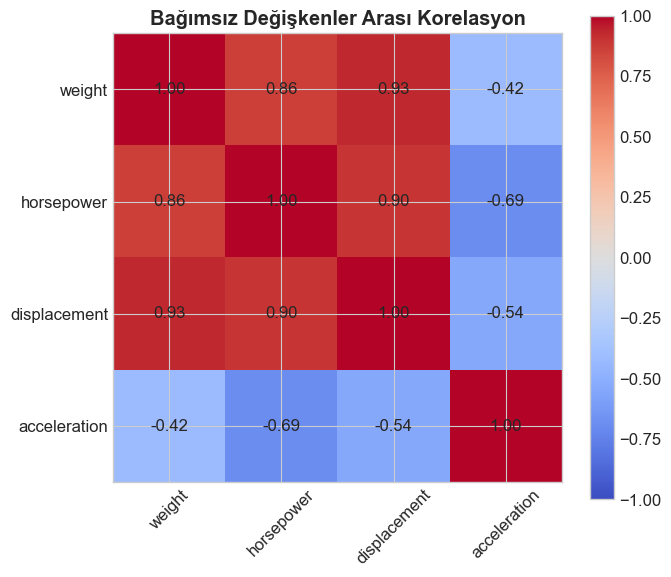

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = auto_temiz[['weight', 'horsepower', 'displacement', 'acceleration']].copy()
X_vif = sm.add_constant(X_vif)  # VIF hesaplamasi icin sabit terim eklenmesi gerekiyor

vif_sonuclari = pd.DataFrame({
    'degisken': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_sonuclari = vif_sonuclari[vif_sonuclari['degisken'] != 'const']
print(vif_sonuclari.to_string(index=False))

print("\nYORUM: VIF > 5 (bazı kaynaklarda >10) endişe verici kabul edilir.")
yuksek_vif = vif_sonuclari[vif_sonuclari['VIF'] > 5]
if len(yuksek_vif) > 0:
    print(f"Yüksek VIF'li değişkenler: {yuksek_vif['degisken'].tolist()}")
    print("Bu değişkenler birbirlerinin bilgisini büyük ölçüde 'tekrar ediyor' - modelin")
    print("bu değişkenlerin bireysel etkisini güvenle ayırt etmesi zor.")

# Gorsel: korelasyon matrisi ile VIF'i birlikte yorumlamak
korelasyon = auto_temiz[['weight', 'horsepower', 'displacement', 'acceleration']].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(korelasyon, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(korelasyon.columns))); ax.set_xticklabels(korelasyon.columns, rotation=45)
ax.set_yticks(range(len(korelasyon.columns))); ax.set_yticklabels(korelasyon.columns)
for i in range(len(korelasyon)):
    for j in range(len(korelasyon)):
        ax.text(j, i, f'{korelasyon.iloc[i,j]:.2f}', ha='center', va='center')
plt.colorbar(im)
ax.set_title('Bağımsız Değişkenler Arası Korelasyon', fontweight='bold')
plt.tight_layout()
plt.show()

---
### 🌪️ Python 4 — Homoscedasticity: Breusch-Pagan Testi (Elle + Kütüphane)

**Ne yapıyoruz?**  
Breusch-Pagan testinin mantığı basit: residual KARELERİNİ, bağımsız değişkenlerle
regresyona sokuyorsun. Eğer bu yardımcı regresyon "anlamlıysa" (residual büyüklüğü X'e bağlıysa),
homoscedasticity ihlal edilmiş demektir. Önce elle kuruyoruz, sonra `statsmodels`'in hazır
fonksiyonuyla doğruluyoruz.

In [6]:
# ===== ELLE BREUSCH-PAGAN =====
residual_kare = residuals ** 2
X_bp = auto_temiz[['weight', 'horsepower', 'displacement', 'acceleration']]
X_bp = sm.add_constant(X_bp)

yardimci_model = sm.OLS(residual_kare, X_bp).fit()
n = len(auto_temiz)
LM_istatistigi = n * yardimci_model.rsquared  # n*R^2 ~ chi-square(df=degisken sayisi)
serbestlik_derecesi = X_bp.shape[1] - 1
p_value_bp_elle = 1 - stats.chi2.cdf(LM_istatistigi, serbestlik_derecesi)

print(f"[ELLE] LM istatistiği: {LM_istatistigi:.4f}, df={serbestlik_derecesi}, p={p_value_bp_elle:.6f}")

# ===== STATSMODELS ILE DOGRULAMA =====
from statsmodels.stats.diagnostic import het_breuschpagan
lm_stat, lm_p, f_stat, f_p = het_breuschpagan(residuals, X_bp)
print(f"[KÜTÜPHANE] LM istatistiği: {lm_stat:.4f}, p={lm_p:.6f}")
print(f"\nİki yöntem örtüşüyor mü? {'EVET ✓' if abs(LM_istatistigi - lm_stat) < 0.01 else 'HAYIR'}")

alpha = 0.05
if lm_p < alpha:
    print(f"\np ({lm_p:.6f}) < α ({alpha}) → H0'ı (homoscedasticity) REDDET: varyans SABİT DEĞİL")
else:
    print(f"\np ({lm_p:.6f}) ≥ α ({alpha}) → homoscedasticity varsayımını reddedemeyiz")

[ELLE] LM istatistiği: 37.2340, df=4, p=0.000000
[KÜTÜPHANE] LM istatistiği: 37.2340, p=0.000000

İki yöntem örtüşüyor mü? EVET ✓

p (0.000000) < α (0.05) → H0'ı (homoscedasticity) REDDET: varyans SABİT DEĞİL


---
### 📐 Python 5 — Normallik Kontrolü: Q-Q Plot + Shapiro-Wilk

**Ne yapıyoruz?**  
Residual'ların Normal dağılıp dağılmadığını hem görsel (Q-Q plot) hem formal test
(Shapiro-Wilk) ile kontrol ediyoruz.

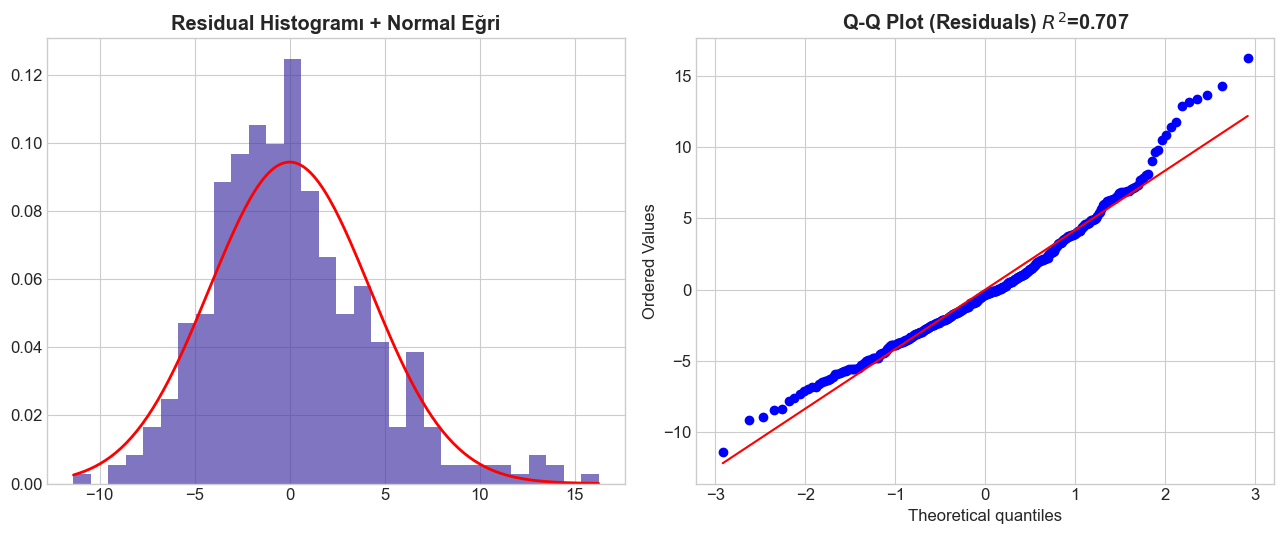

Shapiro-Wilk testi: istatistik=0.9712, p=0.000001
p (0.000001) < 0.05 → H0'ı (normallik) REDDET: residual'lar tam Normal değil

AMA: n=392 oldukça büyük - 06b'deki CLT sayesinde katsayı tahminlerinin
KENDİSİ yine de yaklaşık Normal dağılıyor olabilir. Küçük örneklemde bu ihlal çok daha
endişe verici olurdu. Büyük n, normallik ihlalini kısmen 'affediyor'.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].hist(residuals, bins=30, color='#4a3aa7', alpha=0.7, density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 200)
axes[0].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()), 'red', linewidth=2)
axes[0].set_title('Residual Histogramı + Normal Eğri', fontweight='bold')

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title(f'Q-Q Plot (Residuals) $R^2$={model.rsquared:.3f}', fontweight='bold')

plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk testi: istatistik={shapiro_stat:.4f}, p={shapiro_p:.6f}")

if shapiro_p < 0.05:
    print(f"p ({shapiro_p:.6f}) < 0.05 → H0'ı (normallik) REDDET: residual'lar tam Normal değil")
    print(f"\nAMA: n={len(auto_temiz)} oldukça büyük - 06b'deki CLT sayesinde katsayı tahminlerinin")
    print("KENDİSİ yine de yaklaşık Normal dağılıyor olabilir. Küçük örneklemde bu ihlal çok daha")
    print("endişe verici olurdu. Büyük n, normallik ihlalini kısmen 'affediyor'.")
else:
    print("Normallik varsayımını reddedemeyiz.")

---
### 🔧 Python 6 — Sorunu Çözme: Log Dönüşümü ile Önce/Sonra

**Ne yapıyoruz?**  
Bölüm 2'de gördüğümüz hafif eğriselliği düzeltmek için `mpg`'yi `log(mpg)`'ye dönüştürüp
modeli tekrar kuruyoruz — hem residual grafiğinin hem de Breusch-Pagan sonucunun nasıl
değiştiğine bakacağız.

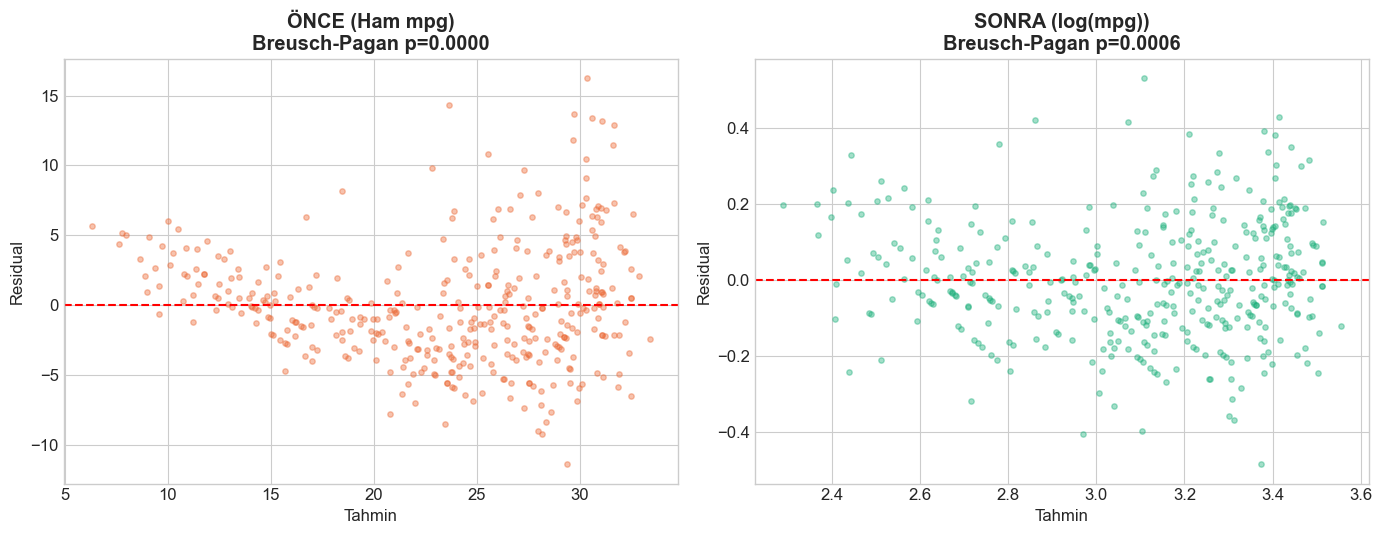

ÖNCE  - R²=0.7070, Breusch-Pagan p=0.000000
SONRA - R²=0.7898, Breusch-Pagan p=0.000602

YORUM: log dönüşümü sonrası Breusch-Pagan p-değeri değişti - eğer sonra ki p-değeri
öncekinden büyükse (homoscedasticity'e daha yakınsa), dönüşüm işe yaramış demektir.
Bu, Bölüm 8'deki 'çözüm haritasının' pratikte nasıl uygulandığının somut bir örneği.


In [10]:
auto_temiz['log_mpg'] = np.log(auto_temiz['mpg'])

model_log = smf.ols('log_mpg ~ weight + horsepower + displacement + acceleration', data=auto_temiz).fit()
tahminler_log = model_log.fittedvalues
residuals_log = model_log.resid

# Log-donusumlu modelde Breusch-Pagan
X_bp_log = sm.add_constant(auto_temiz[['weight', 'horsepower', 'displacement', 'acceleration']])
lm_stat_log, lm_p_log, _, _ = het_breuschpagan(residuals_log, X_bp_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(tahminler, residuals, alpha=0.4, color='#eb6834', s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'ÖNCE (Ham mpg)\nBreusch-Pagan p={lm_p:.4f}', fontweight='bold')
axes[0].set_xlabel('Tahmin'); axes[0].set_ylabel('Residual')

axes[1].scatter(tahminler_log, residuals_log, alpha=0.4, color='#1baf7a', s=15)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title(f'SONRA (log(mpg))\nBreusch-Pagan p={lm_p_log:.4f}', fontweight='bold')
axes[1].set_xlabel('Tahmin'); axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

print(f"ÖNCE  - R²={model.rsquared:.4f}, Breusch-Pagan p={lm_p:.6f}")
print(f"SONRA - R²={model_log.rsquared:.4f}, Breusch-Pagan p={lm_p_log:.6f}")
print("\nYORUM: log dönüşümü sonrası Breusch-Pagan p-değeri değişti - eğer sonra ki p-değeri")
print("öncekinden büyükse (homoscedasticity'e daha yakınsa), dönüşüm işe yaramış demektir.")
print("Bu, Bölüm 8'deki 'çözüm haritasının' pratikte nasıl uygulandığının somut bir örneği.")

---
# 📊 R Uygulaması

R'ın regresyon tanılaması için **base R'a yerleşik** araçları var — `lm()` ile model kurup
`plot(model)` yazman yeterli, R otomatik olarak 4'lü bir diagnostic panel çiziyor. VIF ve
Breusch-Pagan'ı da (harici paket gerektirmeden) elle hesaplayacağız.

In [11]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 🚗 R 1 — Model Kurma ve R'ın Yerleşik 4'lü Diagnostic Paneli

**Yeni R kavramı:** `plot(model)` — bir `lm` nesnesine doğrudan `plot()` uygularsan, R
otomatik olarak Residuals vs Fitted, Q-Q, Scale-Location (homoscedasticity) ve Residuals
vs Leverage grafiklerini üretiyor. Python'da bunun için 3-4 ayrı kod bloğu yazdık, R'da
tek satır.


Call:
lm(formula = mpg ~ weight + horsepower + displacement + acceleration, 
    data = auto_temiz)

Residuals:
    Min      1Q  Median      3Q     Max 
-11.378  -2.793  -0.333   2.193  16.256 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  45.2511397  2.4560447  18.424  < 2e-16 ***
weight       -0.0052805  0.0008109  -6.512  2.3e-10 ***
horsepower   -0.0436077  0.0165735  -2.631  0.00885 ** 
displacement -0.0060009  0.0067093  -0.894  0.37166    
acceleration -0.0231480  0.1256012  -0.184  0.85388    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.247 on 387 degrees of freedom
Multiple R-squared:  0.707,	Adjusted R-squared:  0.704 
F-statistic: 233.4 on 4 and 387 DF,  p-value: < 2.2e-16



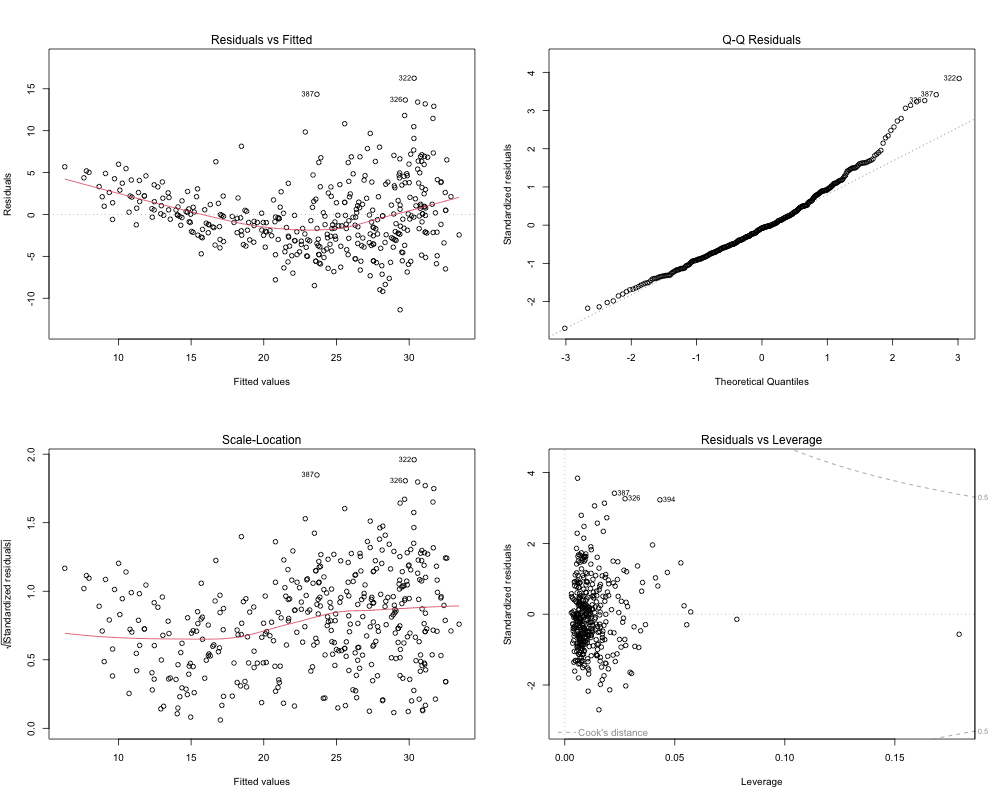

In [12]:
%%R -i auto_temiz -w 1000 -h 800

model_r <- lm(mpg ~ weight + horsepower + displacement + acceleration, data = auto_temiz)
print(summary(model_r))

par(mfrow = c(2, 2))
plot(model_r)
par(mfrow = c(1, 1))

---
### 🔗 R 2 — VIF (Elle Hesaplama)

**Yeni R kavramı yok** — `car::vif()` paketi çok yaygın ama biz güvenilirlik için
(test edilemeyen bağımlılık riski) formülü elle uyguluyoruz, tıpkı Python'da yaptığımız gibi.

In [13]:
%%R

vif_elle <- function(data, degiskenler) {
  sonuclar <- c()
  for (v in degiskenler) {
    diger <- setdiff(degiskenler, v)
    formul <- as.formula(paste(v, "~", paste(diger, collapse = "+")))
    yardimci_model <- lm(formul, data = data)
    r2 <- summary(yardimci_model)$r.squared
    sonuclar[v] <- 1 / (1 - r2)
  }
  sonuclar
}

degiskenler <- c("weight", "horsepower", "displacement", "acceleration")
vif_sonuc_r <- vif_elle(auto_temiz, degiskenler)
print(round(vif_sonuc_r, 3))
cat("\nPython'daki VIF değerleriyle karşılaştır - birebir örtüşmeli.\n")

      weight   horsepower displacement acceleration 
      10.284        8.823       10.687        2.603 

Python'daki VIF değerleriyle karşılaştır - birebir örtüşmeli.


---
### 🌪️ R 3 — Breusch-Pagan Testi (Elle)

**Yeni R kavramı yok** — Python 4'teki mantığın birebir R karşılığı: residual karelerini
bağımsız değişkenlerle regresyona sokup $n \times R^2$'yi ki-kare dağılımıyla karşılaştırma.

In [14]:
%%R

residual_kare_r <- resid(model_r)^2
yardimci_model_r <- lm(residual_kare_r ~ weight + horsepower + displacement + acceleration, data = auto_temiz)

n_r <- nrow(auto_temiz)
LM_istatistigi_r <- n_r * summary(yardimci_model_r)$r.squared
df_r <- length(degiskenler)
p_deger_bp_r <- 1 - pchisq(LM_istatistigi_r, df_r)

cat("LM istatistiği:", LM_istatistigi_r, "\n")
cat("p-değeri:", p_deger_bp_r, "\n")
cat("Python'daki Breusch-Pagan sonucuyla karşılaştır - birebir örtüşmeli.\n")

if (p_deger_bp_r < 0.05) {
  cat("\nH0 (homoscedasticity) reddedildi - varyans sabit değil.\n")
} else {
  cat("\nH0 reddedilemedi.\n")
}

LM istatistiği: 37.23397 
p-değeri: 1.612049e-07 
Python'daki Breusch-Pagan sonucuyla karşılaştır - birebir örtüşmeli.

H0 (homoscedasticity) reddedildi - varyans sabit değil.


---
## ✏️ Egzersizler
---
### **E1 (Python).**
`cylinders` değişkenini de modele ekle (`mpg ~ weight + horsepower +
displacement + acceleration + cylinders`). VIF'leri tekrar hesapla — `cylinders` eklenince
hangi değişkenin VIF'i en çok arttı? Neden (ipucu: motor büyüklüğüyle ilgili tüm değişkenler
birbirine ne kadar yakın)?


 ==== Egzersiz 1: Model Hazırlama ve VIF Hesaplama ====
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     138.0
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          7.79e-108
Time:                        17:09:26   Log-Likelihood:                -1095.3
No. Observations:                 392   AIC:                             2209.
Df Residuals:                     383   BIC:                             2244.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

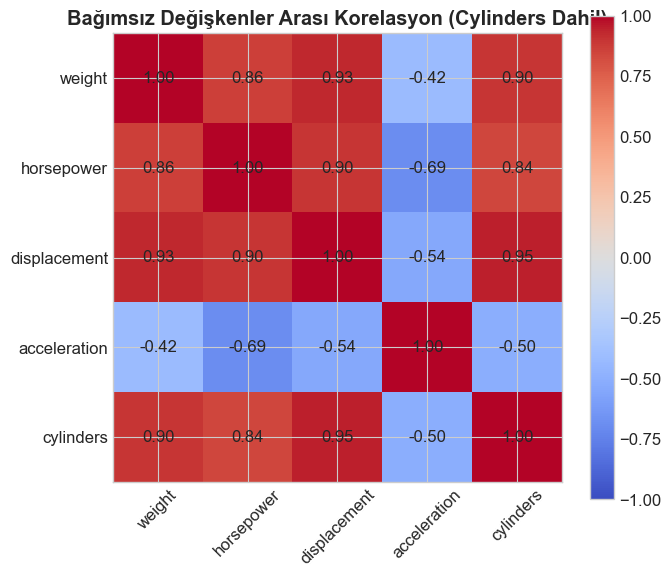

In [17]:
print("\n ==== Egzersiz 1: Model Hazırlama ve VIF Hesaplama ====")

columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
           'acceleration', 'model_year', 'origin', 'car_name']
auto = pd.read_csv('data/auto-mpg.data', sep=r'\s+', names=columns, na_values='?')
auto_clean = auto.dropna(subset=['horsepower']).copy()

model_cyl = smf.ols('mpg ~ weight + horsepower + displacement + acceleration + C(cylinders)', data=auto_clean).fit() 
# mpg bizim bagimli degiskenimiz, weight, horsepower, displacement ve acceleration bagimsiz degiskenlerimiz. C(cylinders) ifadesi ise cylinders degiskeninin kategorik oldugunu belirtmek icin kullaniliyor. 
print(model_cyl.summary())

X_vif = auto_clean[['weight', 'horsepower', 'displacement', 'acceleration', 'cylinders']]
X_vif = sm.add_constant(X_vif)  # VIF hesaplamasi icin sabit terim eklenmesi gerekiyor

vif_results = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_results = vif_results[vif_results['variable'] != 'const']
print("\nVIF Sonuçları (Cylinders Dahil):")
print(vif_results.to_string(index=False))

korelasyon = auto_clean[['weight', 'horsepower', 'displacement', 'acceleration', 'cylinders']].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(korelasyon, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(korelasyon.columns))); ax.set_xticklabels(korelasyon.columns, rotation=45)
ax.set_yticks(range(len(korelasyon.columns))); ax.set_yticklabels(korelasyon.columns)
for i in range(len(korelasyon)):
    for j in range(len(korelasyon)):
        ax.text(j, i, f'{korelasyon.iloc[i,j]:.2f}', ha='center', va='center')
plt.colorbar(im)
ax.set_title('Bağımsız Değişkenler Arası Korelasyon (Cylinders Dahil)', fontweight='bold')
plt.tight_layout()
plt.show()

---

### **E2 (Python).**
 Bölüm 6'daki log dönüşümünü SADECE `mpg`'ye değil, `weight`'e de uygula
(`log(weight)`). Model $R^2$'si ve Breusch-Pagan p-değeri nasıl değişiyor?

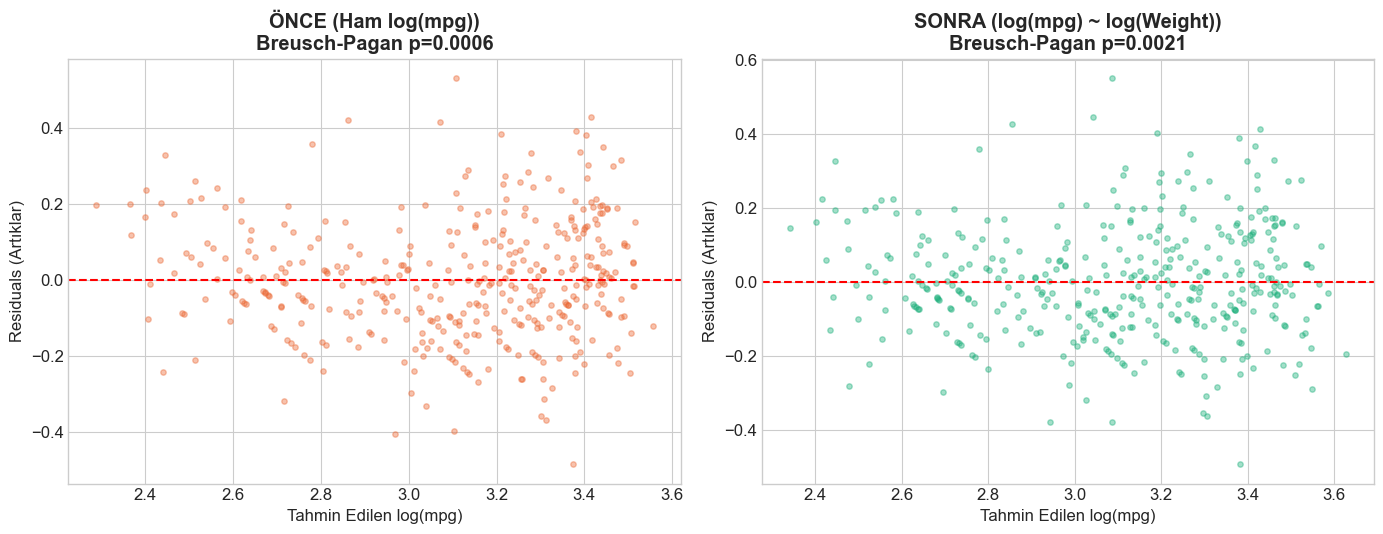

ÖNCE  - R²=0.7898, Breusch-Pagan p=0.000602
SONRA - R²=0.7957, Breusch-Pagan p=0.002086


In [25]:
# --- 1. ÖNCE: Ham (Dönüşümsüz) Modelin Kurulması ve Testi ---
model_ham_log = smf.ols('log_mpg ~ weight + horsepower + displacement + acceleration', data=auto_temiz).fit()
tahminler_ham_log = model_ham_log.fittedvalues
residuals_ham_log = model_ham_log.resid

X_bp_ham_log = sm.add_constant(auto_temiz[['weight', 'horsepower', 'displacement', 'acceleration']])
_, lm_p_ham_log, _, _ = het_breuschpagan(residuals_ham_log, X_bp_ham_log)


# --- 2. SONRA: Log Dönüşümlü Modelin Kurulması ve Testi ---
auto_temiz['log_weight'] = np.log(auto_temiz['weight'])
auto_temiz['log_mpg'] = np.log(auto_temiz['mpg'])

model_log = smf.ols('log_mpg ~ log_weight + horsepower + displacement + acceleration', data=auto_temiz).fit()
tahminler_log = model_log.fittedvalues
residuals_log = model_log.resid

X_bp_log = sm.add_constant(auto_temiz[['log_weight', 'horsepower', 'displacement', 'acceleration']])
_, lm_p_log, _, _ = het_breuschpagan(residuals_log, X_bp_log)


# --- 3. GÖRSELLEŞTİRME: Önce ve Sonra Grafiklerinin Çizilmesi ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Sol Grafik: Ham Model Artıkları
axes[0].scatter(tahminler_ham_log, residuals_ham_log, alpha=0.4, color='#eb6834', s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'ÖNCE (Ham log(mpg))\nBreusch-Pagan p={lm_p_ham_log:.4f}', fontweight='bold')
axes[0].set_xlabel('Tahmin Edilen log(mpg)'); axes[0].set_ylabel('Residuals (Artıklar)')

# Sağ Grafik: Log Dönüşümlü Model Artıkları
axes[1].scatter(tahminler_log, residuals_log, alpha=0.4, color='#1baf7a', s=15)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title(f'SONRA (log(mpg) ~ log(Weight))\nBreusch-Pagan p={lm_p_log:.4f}', fontweight='bold')
axes[1].set_xlabel('Tahmin Edilen log(mpg)'); axes[1].set_ylabel('Residuals (Artıklar)')

plt.tight_layout()
plt.show()

# --- 4. PROGRAMMATİK DOĞRULAMA ÇIKTISI ---
print(f"ÖNCE  - R²={model_ham_log.rsquared:.4f}, Breusch-Pagan p={lm_p_ham_log:.6f}")
print(f"SONRA - R²={model_log.rsquared:.4f}, Breusch-Pagan p={lm_p_log:.6f}")


---

### **E3 (Python + R).**
`origin` değişkenine göre (1/2/3 — üretildiği bölge) ayrı ayrı 3 model
kur, her birinin residual grafiğini incele. Bir bölgenin modeli diğerlerinden daha "sorunlu"
mu (varsayım ihlali açısından)?


 ==== Egzersiz 3: Origin Değişkeni ile Model Kurma ve Test Etme ====
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     193.5
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          8.45e-103
Time:                        17:21:57   Log-Likelihood:                -1115.3
No. Observations:                 392   AIC:                             2243.
Df Residuals:                     386   BIC:                             2266.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

/var/folders/06/61zr6n0n0rs4fbl42p7szkfm0000gn/T/ipykernel_28302/151445611.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[0].set_title(f'{title} - Residuals vs Fitted $p$ = {model.pvalues[1]:.4f}', fontweight='bold')


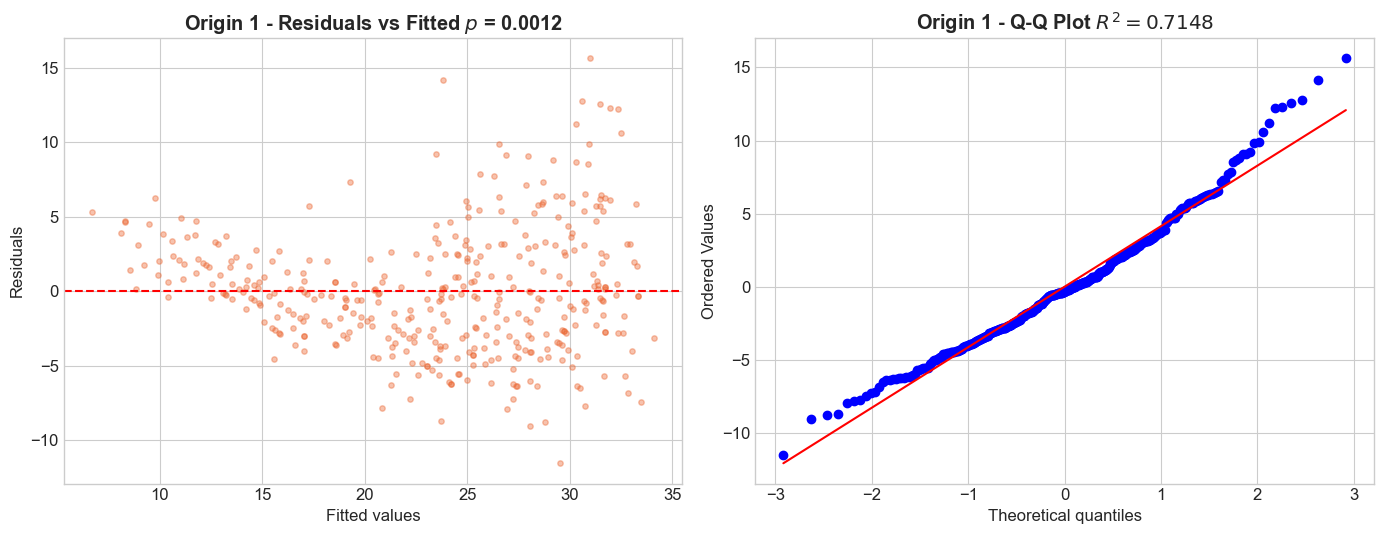

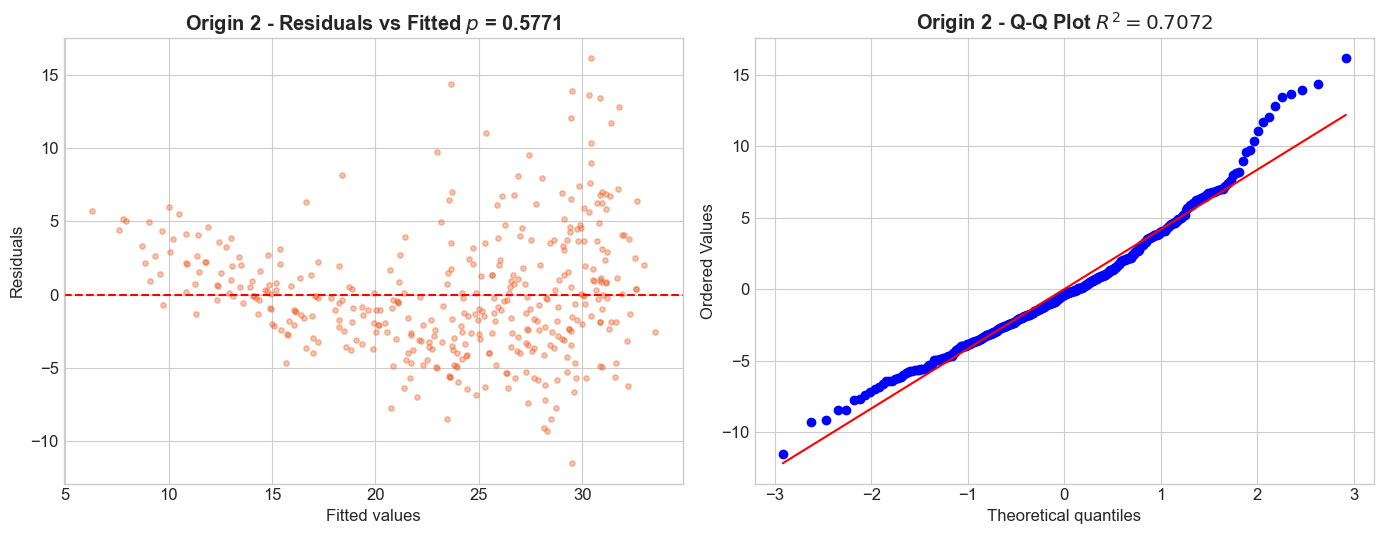

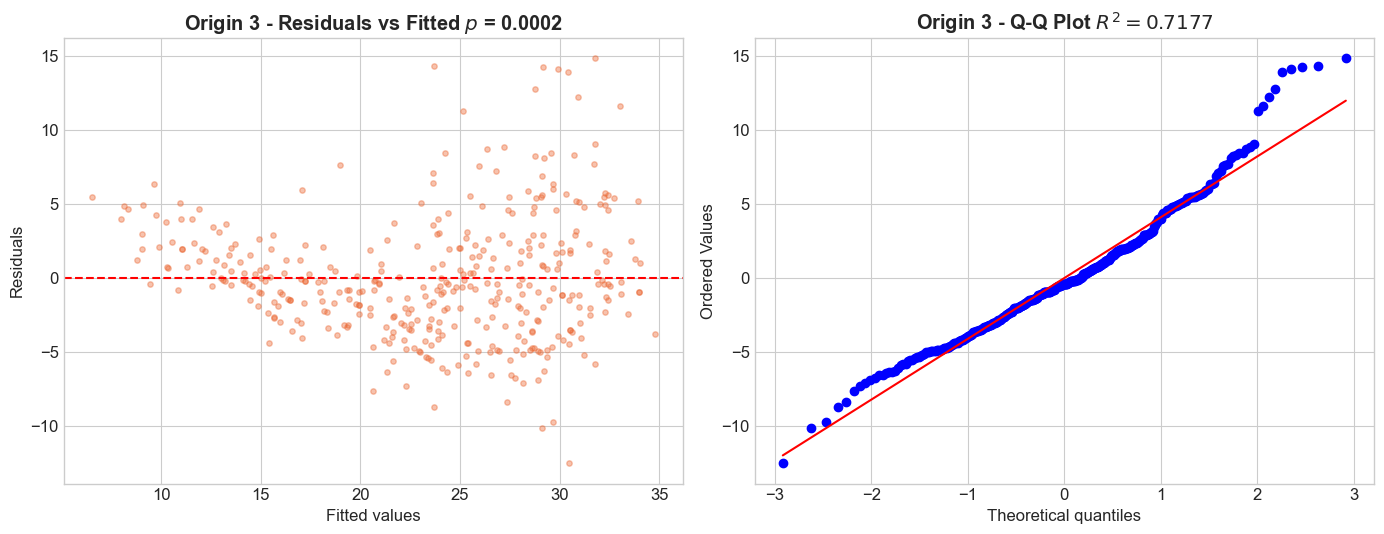

In [36]:
print("\n ==== Egzersiz 3: Origin Değişkeni ile Model Kurma ve Test Etme ====")
model_origin_one= smf.ols('mpg ~ weight + horsepower + displacement + acceleration + origin == 1', data=auto_temiz).fit()
print(model_origin_one.summary())

model_origin_two= smf.ols('mpg ~ weight + horsepower + displacement + acceleration + origin == 2', data=auto_temiz).fit()
print(model_origin_two.summary())

model_origin_three= smf.ols('mpg ~ weight + horsepower + displacement + acceleration + origin == 3', data=auto_temiz).fit()
print(model_origin_three.summary())

# Residuals Graph
for model, title in zip([model_origin_one, model_origin_two, model_origin_three], ['Origin 1', 'Origin 2', 'Origin 3']):
    tahminler = model.fittedvalues
    residuals = model.resid

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    axes[0].scatter(tahminler, residuals, alpha=0.4, color='#eb6834', s=15)
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_title(f'{title} - Residuals vs Fitted $p$ = {model.pvalues[1]:.4f}', fontweight='bold')
    axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')

    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].set_title(f'{title} - Q-Q Plot $R^2 = {model.rsquared:.4f}$', fontweight='bold')

    plt.tight_layout()
    plt.show()

---

### **E4 (R).**
 `model_r`'ın `plot(model_r, which=4)` ile Cook's Distance (etkili gözlem/influential
point tespiti) grafiğini çiz — bu notebook'ta değinmediğimiz ama `plot(model)`'ın verdiği
5. bir tanılama aracı. En yüksek Cook's Distance'a sahip 3 aracı bul, bunları modelden
çıkarıp tekrar kurduğunda katsayılar ne kadar değişiyor?


Call:
lm(formula = mpg ~ weight + horsepower + displacement + acceleration, 
    data = auto_temiz)

Residuals:
    Min      1Q  Median      3Q     Max 
-11.378  -2.793  -0.333   2.193  16.256 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  45.2511397  2.4560447  18.424  < 2e-16 ***
weight       -0.0052805  0.0008109  -6.512  2.3e-10 ***
horsepower   -0.0436077  0.0165735  -2.631  0.00885 ** 
displacement -0.0060009  0.0067093  -0.894  0.37166    
acceleration -0.0231480  0.1256012  -0.184  0.85388    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.247 on 387 degrees of freedom
Multiple R-squared:  0.707,	Adjusted R-squared:  0.704 
F-statistic: 233.4 on 4 and 387 DF,  p-value: < 2.2e-16

Cook's distance > 4/n olan gözlemler: 9 14 59 60 71 95 108 111 116 153 154 165 243 308 321 323 324 325 326 327 328 331 360 382 389 
Cook's distance'e göre en etkili 3 gözlem (araba isimleri):
vw pickup
vw dasher (die

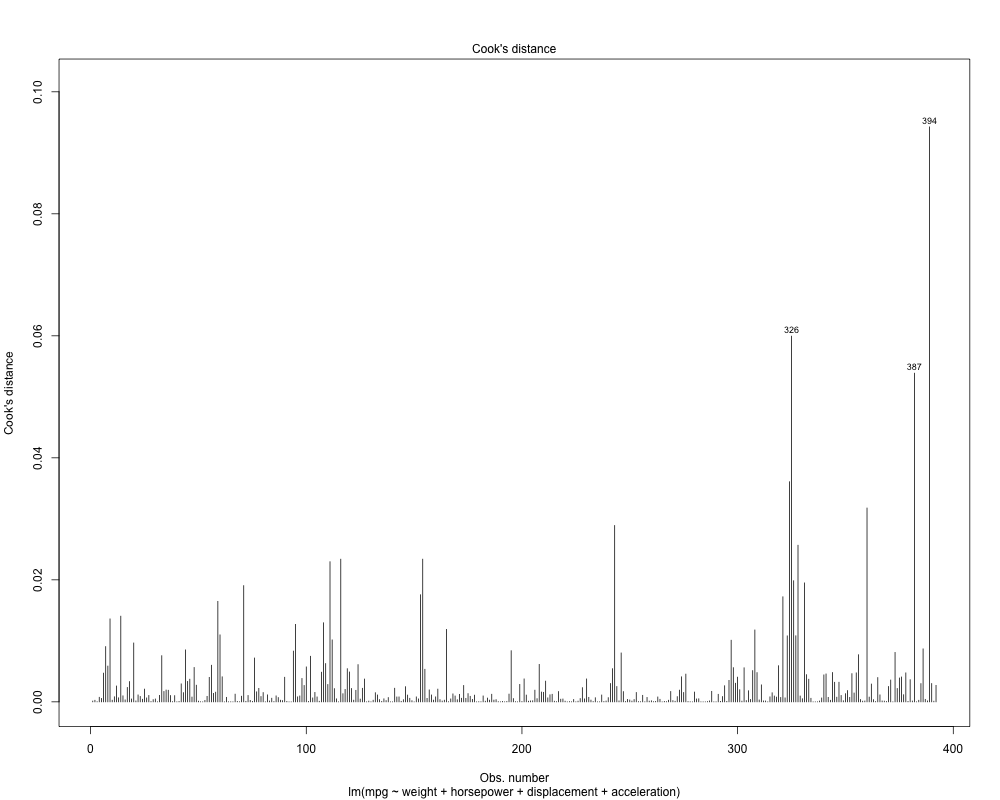

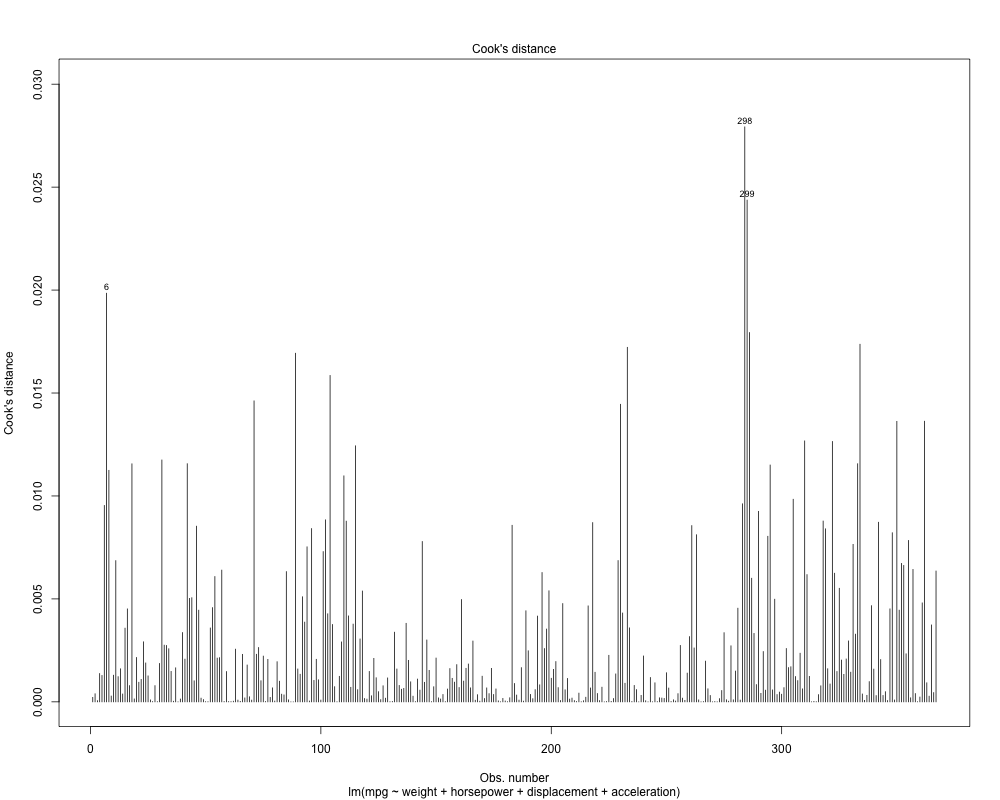

In [52]:
%%R -i auto_temiz -w 1000 -h 800

model_r <- lm(mpg ~ weight + horsepower + displacement + acceleration, data = auto_temiz)
print(summary(model_r))


plot(model_r, which = 4)  # Cook's distance plot

cook_distances <- cooks.distance(model_r)
influential_points <- which(cook_distances > 4 / length(cook_distances))
cat("Cook's distance > 4/n olan gözlemler:", influential_points, "\n")

top_3_cooks <- order(cook_distances, decreasing = TRUE)[1:3]
top_3_cooks_car <- auto_temiz$car_name[top_3_cooks]
cat("Cook's distance'e göre en etkili 3 gözlem (araba isimleri):\n")
cat(top_3_cooks_car, sep = "\n")

cleaned_auto <- auto_temiz[-influential_points, ]

model_cleaned <- lm(mpg ~ weight + horsepower + displacement + acceleration, data = cleaned_auto)
print(summary(model_cleaned))

plot(model_cleaned, which = 4)  # Cook's distance plot for cleaned model

## BONUS = Cook's Distance Nedir?

$$D_i = \frac{\sum_{j=1}^{n} (\hat{y}_j - \hat{y}_{j(i)})^2}{p \cdot s^2}
$$

#### Formül Bileşenleri:

* $(D_{i})$: i. veri noktasının Cook Uzaklığı değeridir. Bu değer büyüdükçe, ilgili gözlemin model üzerindeki etkisi o kadar artar.
* $(\^{y}_{j})$: Tüm veri seti kullanılarak eğitilen orijinal modelin j. gözlem için yaptığı tahmindir.
* $(\^{y}_{j(i)})$: i. gözlem veri setinden çıkarıldıktan sonra modelin yeniden eğitilmesiyle elde edilen j. gözlem tahminidir.
* $s²$: Regresyon modelinin ortalama hata karesidir (Mean Squared Error - MSE). Modelin genel varyansını temsil eder.

Regresyon analizinde, bir regresyon modelin istikrarını etkileyen olağandışı bazı veri noktaları bulunabilir. Bu noktalar kaldırıldığında çıktı çok fazla değişir. Bu noktaları Cook’s Distance ile aramalıyız.

>**Cook’s Distance değeri 1’den büyük olan katılımcılar, problem olarak görülür.**

Cook’s Distance, bir veri setindeki değerlerin bir istatistik modelindeki diğer değerlerden ne kadar fazla sapma gösterdiğini belirlemek için kullanılır. 

Buna, etkili gözlem (influential cases) denir. Etkili gözlem denen şey, uç değer denen şeyden farklıdır. Genellikle regresyon analizinde uç değerleri belirlemenin daha önemli olduğu düşünülse de, etkili gözlem değerlerini belirlemek daha önemlidir.

### Cook’s Distance Ne İçin Kullanılır?

Cook’s Distance, regresyon analizinde, regresyon modelinin katsayılarını veya tahminlerini aşırı derecede etkileyebilecek etkili veri noktalarını belirlemek için kullanılır. Modele dahil edildiğinde veya modelden çıkartıldığında tahmin edilen regresyon katsayılarındaki değişikliklere dayanarak hesaplanır.

Cook’s Distance, veri setindeki her bir gözlem için hesaplanır ve bu gözlem, analizden çıkarıldığında regresyon katsayılarındaki değişikliklere dayanır.

Cook’s Distance değerleri, bir anketi dolduran katılımcılar arasında diğerlerinden belirgin şekilde daha farklı cevap veren katılımcıları belirlemek için kullanılır çünkü bu katılımcıların cevaplarının regresyon modeline büyük etkisi olabilir ve bu da gerçek dünyayı fazla yansıtmayan bir regresyon analizi sonucuna varılmasına sebep olabilir.

*Kaynak: [Cook’s Distance Nedir?](https://www.spss-yardimi.com/cooks-distance-nedir/)*

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 8.4 | OLS'in MLE temeli (`probability-lab` 08 ile bağlantılı) |
| [ISLP (Python)](https://www.statlearning.com) | Ch. 3 | Lineer regresyon ve tanılama — bu notebook'un ana referansı |
| [statsmodels Regression Diagnostics](https://www.statsmodels.org/stable/examples/notebooks/generated/regression_diagnostics.html) | Kütüphane | Bu notebook'ta kullanılan araçların resmi dokümantasyonu |
| [Penn State STAT 501 — Regression Methods](https://online.stat.psu.edu/stat501/) | — | OLS varsayımlarının en detaylı ücretsiz anlatımlarından biri |
| [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg) | Veri | auto-mpg.data kaynağı |